Is it converged? Accuracy, time and the stopping test
=====================================================

**When to use:** you need to know how accurate a solve is, want it faster or more accurate, or see the warning
that a convergence threshold "was not confirmed".

**What you will see:** on 30,000 points, the marginal residual of the plan against the time spent, for fixed-eps
iterations and for annealing schedules, in FP32 and TF32; why the default schedule serves the loss but not the
plan; and what ``threshold`` does and does not certify.

Source: [plot_convergence.py](plot_convergence.py) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

Install `pip install --upgrade 'flash-sinkhorn[notebooks]'`, clone this repository for the example files, and start `jupyter lab` from the checkout. Select its Python environment, then run the cells in order on an NVIDIA CUDA GPU. The setup cell finds the checkout from the repository root or this notebook's folder. The solver comes from the installed package. Running all cells prints fresh results and displays new figures; it also replaces the source's saved images. The scale examples retain the script's full problem sizes.

In [ ]:
# Find this checkout when Jupyter starts at its root or in a notebook folder.
import os
import sys
from pathlib import Path

for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'examples/choosing_parameters/plot_convergence.py').is_file() and (_candidate / "torch-ext/flash_sinkhorn").is_dir():
        _notebook_root = _candidate
        break
else:
    raise RuntimeError("Start Jupyter inside the flash-sinkhorn repository checkout.")

os.chdir(_notebook_root)
# Locate shared example helpers; import the solver from the installed package.
for _path in reversed([_notebook_root / "examples", _notebook_root]):
    if str(_path) in sys.path:
        sys.path.remove(str(_path))
    sys.path.insert(0, str(_path))
__file__ = str(_notebook_root / 'examples/choosing_parameters/plot_convergence.py')

# Display the saved PNG/GIF files explicitly, including figures closed by the source.
import matplotlib
matplotlib.use("Agg")

Setup
-----

In [ ]:
import math
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from flash_sinkhorn import SamplesLoss

sys.path.append(str(Path(__file__).resolve().parents[1]))  # the gallery's shared helpers
from _plotting import SOURCE, TARGET, dense_size, images_dir, require_cuda, save  # noqa: E402
from _transport import marginals  # noqa: E402

device = require_cuda()
torch.manual_seed(0)
n = m = 30_000
x = 0.25 * torch.randn(n, 2, device=device) + torch.tensor([-0.8, 0.0], device=device)
theta = 1.2 + 2.6 * torch.rand(m, device=device)
y = torch.stack([0.6 + 0.8 * torch.cos(theta), 0.8 * torch.sin(theta)], dim=1)
y = y + 0.04 * torch.randn(m, 2, device=device)
a = torch.full((n,), 1.0 / n, device=device)
b = torch.full((m,), 1.0 / m, device=device)
print(dense_size(n, m))
blur = 0.05
eps = blur**2


def residual(f, g):
    """max(|P 1 - a|_1, |P'1 - b|_1): zero for an exact balanced plan."""
    row, col = marginals(x, y, f, g, a, b, eps=eps, cost_scale=0.5)
    return max((row - a).abs().sum().item(), (col - b).abs().sum().item())


def solve(**settings):
    """Potentials and the wall time of the solve."""
    loss = SamplesLoss(blur=blur, half_cost=True, debias=False, backend="symmetric", potentials=True,
                       autotune=False, **settings)
    torch.cuda.synchronize()
    start = time.perf_counter()
    f, g = loss(a, x, b, y)
    torch.cuda.synchronize()
    return f, g, time.perf_counter() - start


for tf32 in (False, True):
    solve(allow_tf32=tf32)  # compile or load both precision variants before timing

Residual against time
---------------------
Two ways to spend iterations: a fixed eps from the start (``use_epsilon_scaling=False``, ``n_iters``), or
annealing eps from the size of the data down to blur^2, faster or slower (``scaling``). Each point is one solve.
At a small blur, annealing reaches a given residual far sooner. The residual below uses FP32 costs on the
original points. Default TF32 rounds centred coordinates for the solve, so that displacement can limit this
residual even after the solve has converged.

In [ ]:
curves = {}
for precision, tf32 in (("FP32", False), ("TF32", True)):
    fixed = []
    for iters in (10, 30, 100, 300, 1000):
        f, g, seconds = solve(use_epsilon_scaling=False, eps=eps, n_iters=iters, allow_tf32=tf32)
        fixed.append((seconds, residual(f, g)))
    annealed = []
    for scaling in (0.5, 0.7, 0.9, 0.95, 0.99):
        f, g, seconds = solve(scaling=scaling, allow_tf32=tf32)
        annealed.append((seconds, residual(f, g)))
    curves[f"fixed eps, {precision}"] = fixed
    curves[f"annealing, {precision}"] = annealed
    for name in (f"fixed eps, {precision}", f"annealing, {precision}"):
        print(name + ": " + ", ".join(f"{s:.2f} s -> {r:.1e}" for s, r in curves[name]))
print(f"peak memory {torch.cuda.max_memory_allocated() / 2**30:.2f} GiB on {torch.cuda.get_device_name()}")

fig, ax = plt.subplots(figsize=(5.5, 4.0))
styles = {"fixed eps, FP32": (SOURCE, "o-"), "annealing, FP32": (TARGET, "s-"),
          "fixed eps, TF32": (SOURCE, "o--"), "annealing, TF32": (TARGET, "s--")}
for name, points in curves.items():
    color, style = styles[name]
    ax.plot([s for s, _ in points], [r for _, r in points], style, color=color, label=name)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(f"seconds per solve ({torch.cuda.get_device_name()})")
ax.set_ylabel("marginal residual")
ax.legend(frameon=False)
save(fig, images_dir(__file__), "convergence")

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/choosing_parameters/images/convergence.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

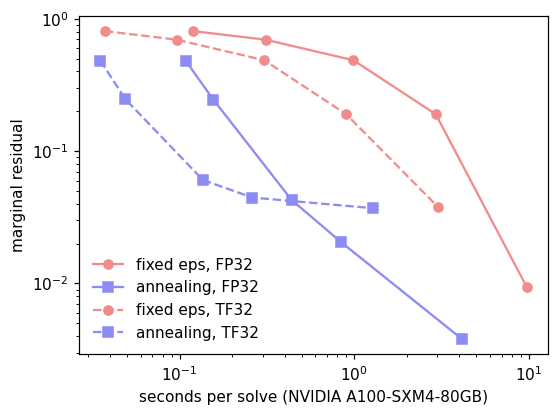

The loss converges before the plan
----------------------------------
The default schedule (``scaling=0.5``) is fast. The loss it returns is close to the converged value even where
the plan's residual is still large, which is why it is the default for losses and gradients; read plans from
a slower FP32 solve.

In [ ]:
debiased = {s: SamplesLoss(blur=blur, half_cost=True, debias=True, backend="symmetric", scaling=s,
                           allow_tf32=False, autotune=False)(a, x, b, y).item() for s in (0.5, 0.99)}
print(f"S_eps, scaling 0.5: {debiased[0.5]:.6f}; scaling 0.99: {debiased[0.99]:.6f}; "
      f"relative difference {abs(debiased[0.5] - debiased[0.99]) / debiased[0.99]:.1e}")

What ``threshold`` certifies
----------------------------
``threshold`` stops the iterations once the potentials change by less than it between two checks
(``inner_iterations`` apart) at the target eps. The automatic schedule ends with a single step at the target
eps, so the test never runs and a warning says so; a schedule that repeats the target eps gives it room. Passing
the test is not a bound on the marginal residual: compute that yourself, as above.

In [ ]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    solve(threshold=1e-4, allow_tf32=False)
print("default schedule:", [str(w.message)[:100] for w in caught] or "no warning")
size = (torch.cat([x, y]).amax(dim=0) - torch.cat([x, y]).amin(dim=0)).norm().item()
steps = math.ceil(math.log(size / blur) / math.log(1 / 0.9))
schedule = [max(eps, size**2 * 0.81**k) for k in range(steps + 1)] + [eps] * 2000
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    f, g, seconds = solve(eps_list=schedule, threshold=1e-4, inner_iterations=10, allow_tf32=False)
print(f"schedule repeating the target eps: {[str(w.message)[:100] for w in caught] or 'no warning'}; "
      f"{seconds:.2f} s, marginal residual {residual(f, g):.1e}")
plt.show()